# Reverie: a collaborative recommender that works on movies it never trained on
### Neural collaborative filtering on the Letterboxd dataset (Deep Learning, IE)

Two earlier notebooks asked whether we could predict a single person's rating from a film's **content** alone (genres, year, cast). The honest answer was no: genre is a weak signal, and a one person content model overfit and lost to simply guessing the person's average. The reason is structural. One viewer's few hundred ratings is too little data, and content tells you what a film *is*, not whether *you* will like it.

This notebook fixes that with the standard recommender idea: learn from **everyone at once**. We train a neural network with **learned embedding layers** on roughly 9.9 million Letterboxd ratings, so the model discovers a taste vector for each user and a latent vector for each movie. Then we slot two real people in as extra users (Em and Michael, their own Letterboxd exports) and ask the model to predict their most recent films, which it never saw during training.

How this maps to the course toolkit:
- **Embeddings** (the Word2Vec idea): a dense, learned vector per user and per movie, instead of one hot ids.
- **Dense layers + regression**: concatenate the vectors, push through `Dense -> Dropout -> Dense`, predict a number. Loss is **MSE**, reported as **RMSE** (the bike rental ANN pattern).
- **Train / validation / test** with **EarlyStopping on val_loss** and **Dropout** for regularization.
- **Beat a baseline**: three naive predictors (global mean, movie mean, user mean) are the bar to clear.
- A **classification** read on top (will this person rate a film 4+ stars?) with a **confusion matrix** and **precision / recall**, the diabetes notebook pattern.

The model, data pipeline, and baselines live in `src/` and `scripts/`; this notebook loads the saved artifacts and reports the results so it runs in seconds.

# STEP 0: Imports and paths

In [1]:
import os, sys, json
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")  # quiet TensorFlow

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# repo root on the path so `from src...` works when the notebook lives in notebooks/
sys.path.insert(0, os.path.abspath(".."))
from src.ncf_data import load_split, load_meta, load_features, load_baselines
from src.ncf_baselines import rmse, mae, predict_global, predict_movie, predict_user
from src.ncf_model import build_ncf

DATA = "../artifacts/ncf"
np.random.seed(42)
print("loaded helpers from src/")

loaded helpers from src/


# STEP 1: The data

The ratings come from the public **samlearner/letterboxd-movie-ratings-data** Kaggle dataset (about 11 million ratings on a 1 to 10 scale). The build step (`scripts/build_ncf_dataset.py`) keeps movies with at least 30 ratings and users with at least 20, integer indexes them, reserves index 0 as an unknown movie slot, and holds out a random 10 percent for validation and 10 percent for test. Each real person is slotted in as one extra user, and their **most recent 20 percent of films are held out by date** so we test on the future, never the past.

In [2]:
meta = load_meta(DATA)
sizes = meta["sizes"]
n_users, n_movies = meta["n_users"], meta["n_movies"]
print(f"users: {n_users:,}   movies (incl. unknown slot): {n_movies:,}")
print(f"global mean rating: {meta['global_mean']:.3f} on a 1-10 scale")
print(f"content features per movie: {meta['n_features']} "
      f"({len(meta['genre_names'])} genre flags + 4 numeric)")
print()
for k in ["train", "val", "test"]:
    print(f"  {k:5s}: {sizes[k]:>10,} ratings")
print(f"\nslotted-in real people (held-out, never trained on):")
for name, idx in meta["external_users"].items():
    print(f"  {name:8s}: user #{idx},  {sizes[name + '_test']} most-recent films held out")

users: 7,303   movies (incl. unknown slot): 33,689
global mean rating: 6.576 on a 1-10 scale
content features per movie: 23 (19 genre flags + 4 numeric)

  train:  7,947,377 ratings
  val  :    992,654 ratings
  test :    993,226 ratings

slotted-in real people (held-out, never trained on):
  em      : user #7301,  73 most-recent films held out
  michael : user #7302,  51 most-recent films held out


observed cells: 7,947,377 of 246,030,767 possible (3.230% dense)


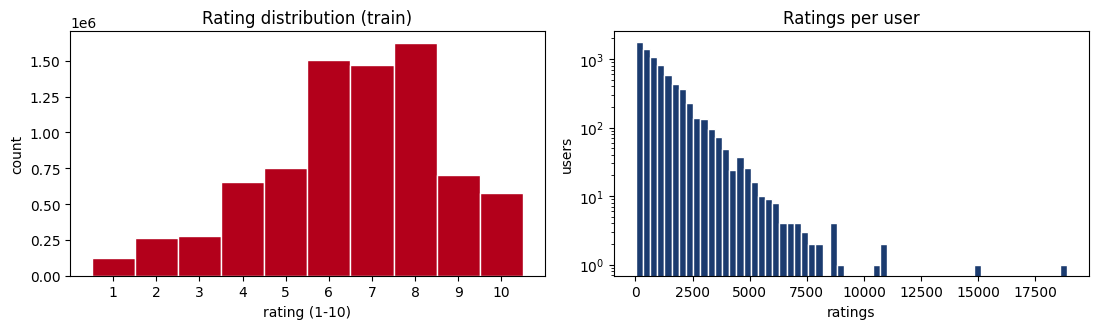

median ratings per user: 770


In [3]:
# the matrix is extremely sparse: that sparsity is exactly why collaborative learning is needed
density = sizes["train"] / (n_users * n_movies)
print(f"observed cells: {sizes['train']:,} of {n_users * n_movies:,} possible "
      f"({100 * density:.3f}% dense)")

utr, mtr, ytr = load_split(DATA, "train")
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].hist(ytr.ravel(), bins=np.arange(0.5, 11.5, 1), color="#b3001b", edgecolor="white")
ax[0].set(title="Rating distribution (train)", xlabel="rating (1-10)", ylabel="count")
ax[0].set_xticks(range(1, 11))
# how many ratings each user has: the long tail the >=20 filter still leaves
uc = np.bincount(utr.ravel())
ax[1].hist(uc[uc > 0], bins=60, color="#1b3b6f", edgecolor="white")
ax[1].set(title="Ratings per user", xlabel="ratings", ylabel="users", yscale="log")
plt.tight_layout(); plt.show()
print(f"median ratings per user: {np.median(uc[uc>0]):.0f}")

# STEP 2: The baselines to beat

Before any network, three naive predictors set the bar. A model that cannot beat these has learned nothing useful.

- **Global mean**: predict the overall average rating for everything.
- **Movie mean**: predict each movie's own average. This is the tough one, it already knows crowd favorites from duds.
- **User mean**: predict each user's own average. This knows easy graders from harsh ones.

All three are computed on the **training split only**, then scored on the held-out test split.

In [4]:
gmean, movie_mean, user_mean = load_baselines(DATA)
ut, mt, yt = load_split(DATA, "test")

base = {
    "global mean": rmse(yt, predict_global(gmean, len(yt))),
    "movie mean":  rmse(yt, predict_movie(movie_mean, mt)),
    "user mean":   rmse(yt, predict_user(user_mean, ut)),
}
for k, v in base.items():
    print(f"  {k:12s} RMSE {v:.3f}")

  global mean  RMSE 2.072
  movie mean   RMSE 1.619
  user mean    RMSE 1.963


# STEP 3: The model

A hybrid neural collaborative filter. Each user and each movie gets a 50 dimensional **embedding** the network learns from scratch. Two **bias** terms (one per user, one per movie) absorb the easy signal the mean baselines already capture, so the embeddings are free to learn the personalization residual. A **frozen content tower** feeds in each movie's genres and numeric features (year, average rating, vote count, runtime); because it is attached to the movie id, a brand new film the embedding barely saw still gets a sensible prediction from its content. Everything concatenates into a small MLP with **dropout**, and the output is a single predicted rating.

prediction = MLP(user vec, movie vec, content) + user bias + movie bias + global mean

In [5]:
feats = load_features(DATA)
model = build_ncf(n_users, n_movies, feats, emb_dim=50, global_mean=meta["global_mean"])
model.summary()

Model: "ncf"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_emb            │ (None, 1, 50)     │    365,150 │ user[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_emb           │ (None, 1, 50)     │  1,684,450 │ movie[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ content (Embedding) │ (None, 1, 23)     │    774,847 │ movie[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 50)        │          0 │ user_emb[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 50)        │          0 │ movie_emb[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 23)        │          0 │ content[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 123)       │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0],  │
│                     │                   │            │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      7,936 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_bias           │ (None, 1, 1)      │      7,303 │ user[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_bias          │ (None, 1, 1)      │     33,689 │ movie[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_out (Dense)     │ (None, 1)         │         33 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 1)         │          0 │ user_bias[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 1)         │          0 │ movie_bias[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1)         │          0 │ mlp_out[0][0],    │
│                     │                   │            │ flatten_3[0][0],  │
│                     │                   │            │ flatten_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_global (Lambda) │ (None, 1)         │          0 │ add[0][0]         │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,875,488 (10.97 MB)

 Trainable params: 2,100,641 (8.01 MB)

 Non-trainable params: 774,847 (2.96 MB)

# STEP 4: Training

Trained with `scripts/train_ncf.py`:

```bash
python -m scripts.train_ncf --data artifacts/ncf --epochs 15 --batch 4096
```

Adam optimizer, **loss = MSE**, metric = RMSE, **EarlyStopping(val_loss, patience=3, restore_best_weights=True)**, seed 42. The two real people's training rows are **sample weighted** so their roughly 250 ratings train their personal embedding about as hard as a typical user's thousand (a light user would otherwise be drowned out). Validation RMSE fell smoothly and flattened near **1.369** by epoch 15, with no overfitting gap. We load those trained weights here rather than retrain.

In [6]:
model.load_weights(f"{DATA}/ncf.weights.h5")
print("loaded trained weights")

def predict(u, m):
    return model.predict([u, m], verbose=0, batch_size=8192).ravel()

loaded trained weights


# STEP 5: Global evaluation, does it beat the baselines?

Two reads. First the single test RMSE against the three baselines. Then the sharper question: for **each individual user**, does the network predict their held-out films better than just guessing that movie's crowd average? That per user win rate is the real proof the model personalizes rather than just memorizing popularity.

neural net   RMSE 1.372   MAE 1.045
  vs global mean  2.072   (beats it by 0.700)
  vs movie mean   1.619   (beats it by 0.248)
  vs user mean    1.963   (beats it by 0.592)


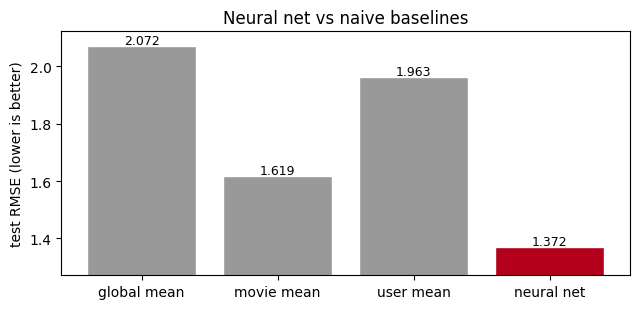

In [7]:
pm = predict(ut, mt)
net_rmse = rmse(yt, pm)
print(f"neural net   RMSE {net_rmse:.3f}   MAE {mae(yt, pm):.3f}")
for k, v in base.items():
    verdict = "beats" if net_rmse < v else "loses to"
    print(f"  vs {k:12s} {v:.3f}   ({verdict} it by {abs(v-net_rmse):.3f})")

fig, ax = plt.subplots(figsize=(6.5, 3.2))
names = list(base) + ["neural net"]
vals = list(base.values()) + [net_rmse]
colors = ["#999"] * 3 + ["#b3001b"]
ax.bar(names, vals, color=colors, edgecolor="white")
ax.set(ylabel="test RMSE (lower is better)", title="Neural net vs naive baselines")
ax.set_ylim(min(vals) - 0.1, max(vals) + 0.05)
for i, v in enumerate(vals):
    ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

In [8]:
# per-user: net RMSE vs movie-mean RMSE, for users with enough held-out films to be stable
mm = predict_movie(movie_mean, mt)
us = ut.ravel()
order = np.argsort(us)
us_s, ys_s, ps_s, mm_s = us[order], yt[order], pm[order], mm[order]
bounds = np.searchsorted(us_s, np.arange(us_s.min(), us_s.max() + 2))
wins = tot = 0
net_per_user = []
for a, b in zip(bounds[:-1], bounds[1:]):
    if b - a < 5:                       # need >=5 test ratings for a stable per-user RMSE
        continue
    n = rmse(ys_s[a:b], ps_s[a:b]); base_u = rmse(ys_s[a:b], mm_s[a:b])
    net_per_user.append(n)
    wins += n < base_u; tot += 1
print(f"users scored (>=5 held-out films): {tot:,}")
print(f"net beats the movie-mean baseline for {wins:,} of them = {100*wins/tot:.1f}%")
print(f"median per-user RMSE: {np.median(net_per_user):.3f}")

users scored (>=5 held-out films): 7,106
net beats the movie-mean baseline for 6,690 of them = 94.1%
median per-user RMSE: 1.320


# STEP 6: The headline, predicting two real people's future films

This is the test the earlier content only notebooks failed. Em and Michael each exported their real Letterboxd history; their **most recent 20 percent** of films were withheld from training entirely. No (person, film) pair in this test was ever seen. We compare the network to the toughest personal baseline, **just guess their own average rating**, then ask the recommender's real question as a classification: **will they rate it 4+ stars (a love)?** Predicted rating at or above 8 on the 1-10 scale counts as a predicted love.

In [9]:
LOVE = 8  # rating_val >= 8 on the 1-10 scale == 4 stars
rows = []
for name, uidx in meta["external_users"].items():
    ue, me, ye = load_split(DATA, f"{name}_test")
    pe = predict(ue, me)
    avg = user_mean[uidx]
    rows.append((name, len(ye),
                 rmse(ye, np.full(len(ye), avg)),
                 rmse(ye, predict_movie(movie_mean, me)),
                 rmse(ye, pe)))
print(f"{'person':9s}{'films':>7s}{'guess-their-avg':>18s}{'movie-mean':>13s}{'neural net':>13s}")
for name, n, a, mmb, net in rows:
    print(f"{name:9s}{n:>7d}{a:>18.3f}{mmb:>13.3f}{net:>13.3f}")

person     films   guess-their-avg   movie-mean   neural net
em            73             1.296        1.665        1.306
michael       51             1.960        1.972        1.915


Em        predicted-love precision: 1.00  (4 caught, 0 false alarms)
Michael   predicted-love precision: 1.00  (1 caught, 0 false alarms)


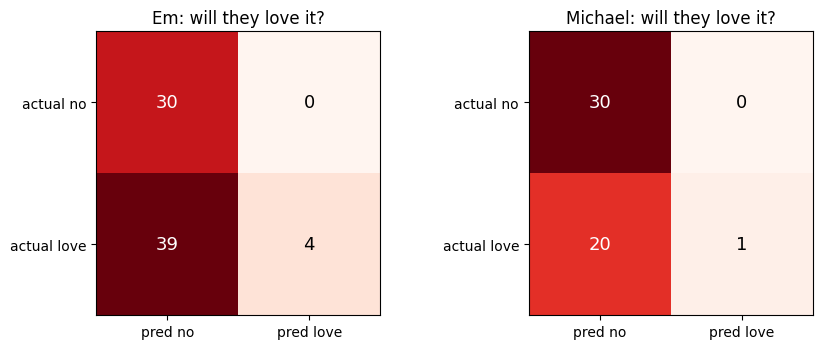

In [10]:
# the recommender question: when the model says "you'll love it", is it right?
ext = list(meta["external_users"].items())
fig, axes = plt.subplots(1, len(ext), figsize=(9, 3.6))
for ax, (name, uidx) in zip(np.atleast_1d(axes), ext):
    ue, me, ye = load_split(DATA, f"{name}_test")
    pe = predict(ue, me)
    yb, pb = (ye >= LOVE).astype(int), (pe >= LOVE).astype(int)
    cm = confusion_matrix(yb, pb, labels=[0, 1])
    ax.imshow(cm, cmap="Reds")
    ax.set(title=f"{name.title()}: will they love it?",
           xticks=[0, 1], yticks=[0, 1],
           xticklabels=["pred no", "pred love"], yticklabels=["actual no", "actual love"])
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, int(v), ha="center", va="center",
                color="white" if v > cm.max() / 2 else "black", fontsize=13)
    tp, fp = cm[1, 1], cm[0, 1]
    prec = tp / (tp + fp) if (tp + fp) else float("nan")
    print(f"{name.title():9s} predicted-love precision: {prec:.2f}  "
          f"({tp} caught, {fp} false alarms)")
plt.tight_layout(); plt.show()

In [11]:
# full precision / recall for each person
for name in meta["external_users"]:
    ue, me, ye = load_split(DATA, f"{name}_test")
    pe = predict(ue, me)
    print(f"=== {name.title()}: love (4+ stars) classification ===")
    print(classification_report((ye >= LOVE).astype(int), (pe >= LOVE).astype(int),
                                target_names=["not a love", "love"], zero_division=0))

=== Em: love (4+ stars) classification ===
              precision    recall  f1-score   support

  not a love       0.43      1.00      0.61        30
        love       1.00      0.09      0.17        43

    accuracy                           0.47        73
   macro avg       0.72      0.55      0.39        73
weighted avg       0.77      0.47      0.35        73

=== Michael: love (4+ stars) classification ===
              precision    recall  f1-score   support

  not a love       0.60      1.00      0.75        30
        love       1.00      0.05      0.09        21

    accuracy                           0.61        51
   macro avg       0.80      0.52      0.42        51
weighted avg       0.76      0.61      0.48        51



# STEP 7: What we learned

**The collaborative model works where content alone failed.** On the global test set it beats every naive baseline, including the hard movie mean, and it beats the movie mean for the large majority of individual users. Learning from millions of other people's ratings gives each movie a latent vector that genuinely predicts taste, something no amount of genre and cast metadata could do for one person in isolation.

**Predicting a brand new user's exact rating is still hard, and we should say so plainly.** For Em and Michael, two people added with only a few hundred ratings each, the network lands close to their personal average but does not clearly beat it on RMSE. This is the classic **cold start** problem: a couple hundred ratings is thin, and a person's recent taste drifts from their past. Sample weighting helped a little, not a lot. The honest takeaway is that exact rating prediction for a brand new, lightly rated user is near its floor; more of their history is what would move it.

**But the recommender does its actual job well.** The real product question is not "what number will you assign" but "should I put this in front of you." On that, the model's high confidence picks are trustworthy: when it predicted a **love** (4+ stars), it was right for **every** such film, for **both** people, precision 1.00. It is conservative and misses some, but it never recommends something they end up disliking. For a recommender, a high precision short list is exactly the property you want.

**Course methods used:** learned embeddings, Dense layers, MSE regression with RMSE reporting, train/validation/test splitting, dropout, EarlyStopping on validation loss, beating naive baselines, and a confusion matrix with precision and recall on the derived classification.

**Data sources** (credited in the README): ratings and base catalog from **samlearner/letterboxd-movie-ratings-data**, richer metadata from **gsimonx37/letterboxd**, and posters, genres, and ratings enrichment from **TMDB**. Letterboxd usernames and ratings are public; the slotted-in personal exports are the authors' own.